# Evaluate Generation on Unseen Protocols.

## Prepare Notebook.

### Import Libraries.

In [66]:
import os
import sys
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

from sc_exp_design.metrics import compute_e_distance
from sc_exp_design.models import FlowMatching, TargetPredictionModel

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import (
    get_shuffled_populations,
)
from data_utils import (
    annotate_perturbations,
    get_protocol_tranformations,
    standardize_array_and_write_to_adata,
)

### Constants and Paths.

In [67]:
h5ad_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/LPHO012/projected_LPHO12_all_exp.h5ad"

simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_01-28-16_807188d0"

metadata_csv_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/table_metadata_theis_unmix8.xlsx"
annotation_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/forward/conditional_model/flow_matching/config/annotation/default.yaml"
dump_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_01-28-16_807188d0/plots"
model_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-02-11_20-04-08/neat-violet-213_FlowMatching.pkl"
classifier_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl"

config_path = os.path.join(simulation_data_dir, "config.yaml")
results_path = os.path.join(simulation_data_dir, "fwd_results.npz")
cond_data_path = os.path.join(simulation_data_dir, "condition_data.pkl")

experiment_id = "LPHO012"

### Read Data.

### Load Model.

In [ ]:
cfm = FlowMatching.load(model_path)
classifier = TargetPredictionModel.load(classifier_path)

### Read Annotation configurations.

In [4]:
with open(annotation_config_path, "r") as fb:
    ann_config = yaml.safe_load(fb)
protocol_cols = ann_config["protocol_columns"]

### Read real measurements.

In [5]:
adata_real = sc.read_h5ad(h5ad_path)
le_ct = LabelEncoder().fit(adata_real.obs["cell_type"])
adata_real

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'Unnamed: 25', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'cell_type', 'annotation_final'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'meta', 'processing_steps'
    obsm: 'X_pca', 'X_umap', 'rep'
    layers: 'positives', 'raw'

### Annotate condition data.

In [34]:
column2tranform = get_protocol_tranformations(
    protocol_cols,
    log1p_exp_cols=ann_config["log1p_exp_cols"],
    log21p_exp_cols=ann_config["log21p_exp_cols"],
    inverse=False,
)

adata_real = annotate_perturbations(
    adata_real,
    protocol_cols,
    protocol_obs_key_added=ann_config["protocol_obs_key_added"],
    protocol_sep=ann_config["protocol_sep"],
    one_hot_uns_key_added=ann_config["one_hot_uns_key_added"],
    column2tranform=column2tranform,
)

gm-csf_[ng_ml] <ufunc 'log1p'> [[10.]
 [10.]
 [ 0.]
 ...
 [10.]
 [10.]
 [10.]] float64
tpo_[ng_ml] <ufunc 'log1p'> [[2.5]
 [2.5]
 [0. ]
 ...
 [2.5]
 [2.5]
 [2.5]] float64
sr1_[nm] <ufunc 'log1p'> [[  0]
 [375]
 [  0]
 ...
 [375]
 [750]
 [ 75]] int64
um171_[nm] <ufunc 'log1p'> [[560]
 [560]
 [ 70]
 ...
 [560]
 [560]
 [560]] int64
um729_[µm] <ufunc 'log1p'> [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]] float64
scf_[ng_ml] <ufunc 'log1p'> [[10]
 [10]
 [ 0]
 ...
 [10]
 [10]
 [10]] int64
butyzamide_[nm] <ufunc 'log1p'> [[  0]
 [  0]
 [100]
 ...
 [  0]
 [  0]
 [  0]] int64
retinoic_acid_[µm] <ufunc 'log1p'> [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]] int64
ldl_[ng_ml] <ufunc 'log1p'> [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]] int64
il3_[ng_ml] <ufunc 'log1p'> [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]] float64
o2_[%] <ufunc 'log1p'> [[20]
 [20]
 [20]
 ...
 [20]
 [20]
 [20]] int64
days_of_culture <ufunc 'log1p'> [[14]
 [14]
 [14]
 ...
 [14]
 [14]
 [14]] int64


### Renormalizing reference data.

In [93]:
adata_class = classifier.train_data.adata
adata_ref = cfm.train_data.adata

X_channel_params_class = adata_class.uns["X_channel_params"]
X_scatter_params_class = adata_class.uns["X_scatter_params"]

X_channel_params_ref = adata_ref.uns["X_channel_params"]
X_scatter_params_ref = adata_ref.uns["X_scatter_params"]

X_channel_standardized_classifier = adata_class.obsm["X_channel_standardized"]
X_scatter_standardized_classifier = adata_class.obsm["X_scatter_standardized"]

X_channel_classifier = X_channel_standardized_classifier*X_channel_params_class["std"] + X_channel_params_class["mean"]
X_scatter_classifier = X_scatter_standardized_classifier*X_scatter_params_class["std"] + X_scatter_params_class["mean"]

X_channel_classifier_renormalized = (X_channel_classifier - X_channel_params_ref["mean"])/X_channel_params_ref["std"]
X_scatter_classifier_renormalized = (X_scatter_classifier - X_scatter_params_ref["mean"])/X_scatter_params_ref["std"]

adata_class.obsm["X_channel_renormalized"] = X_channel_classifier_renormalized
adata_class.obsm["X_scatter_renormalized"] = X_scatter_classifier_renormalized

### Applying standardization on cell states.

In [95]:
X_scatter = adata_real.obs[ann_config["scatter_columns"]].values
X_channel = adata_real.X

X_channel_standardized = (X_channel - X_channel_params_ref["mean"])/X_channel_params_ref["std"]
X_scatter_standardized = (X_scatter - X_scatter_params_ref["mean"])/X_scatter_params_ref["std"]

adata_real.obsm["X_channel_standardized"] = X_channel_standardized
adata_real.obsm["X_scatter_standardized"] = X_scatter_standardized

### Read metadaata csv.

In [6]:
metadata_df = pd.read_excel(metadata_csv_path)
metadata_df.columns = [c.replace("/", "_") for c in metadata_df.columns]
metadata_df = metadata_df.loc[
    metadata_df["experiment_id"] == "LPHO012",
    protocol_cols + ["experiment_number", "experiment_id"]
]
metadata_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,experiment_number,experiment_id
262,10,2.5,750,560.0,0.0,10,0,0,0,0.0,20,14,205,LPHO012
263,10,2.5,375,560.0,0.0,10,0,0,0,0.0,20,14,206,LPHO012
264,10,2.5,75,560.0,0.0,10,0,0,0,0.0,20,14,207,LPHO012
265,10,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14,208,LPHO012
266,0,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14,209,LPHO012
267,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14,210,LPHO012


### Read simulated data.

In [8]:
sim_data = np.load(results_path)
sim_data.keys()

KeysView(NpzFile '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_01-28-16_807188d0/fwd_results.npz' with keys: X, X_channel, X_scatter, ct_logits, ct_probs)

## Evaluating Predictions.

### Prepare Plot Data.

/tmp/ipykernel_2628400/4191261310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (exp_number, exp_idx) in enumerate(adata_real.obs.groupby("experiment_number").groups.items()):


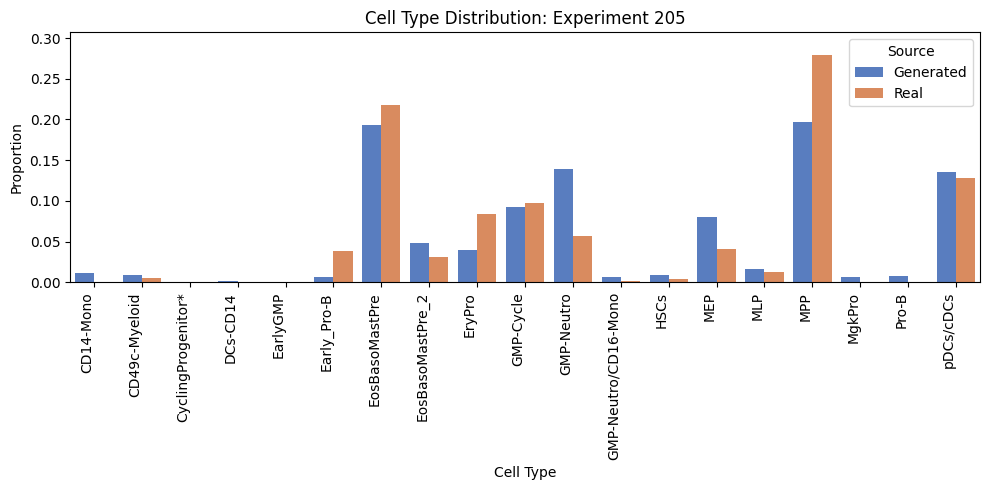

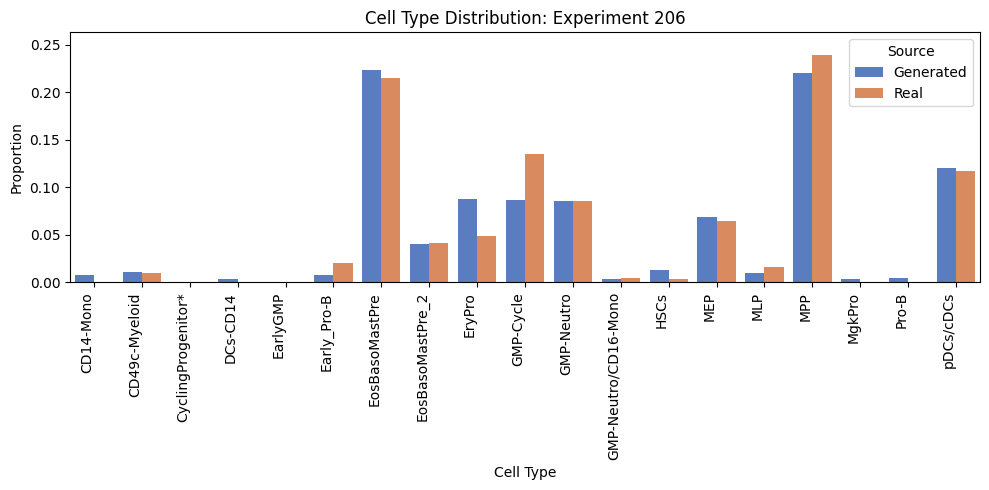

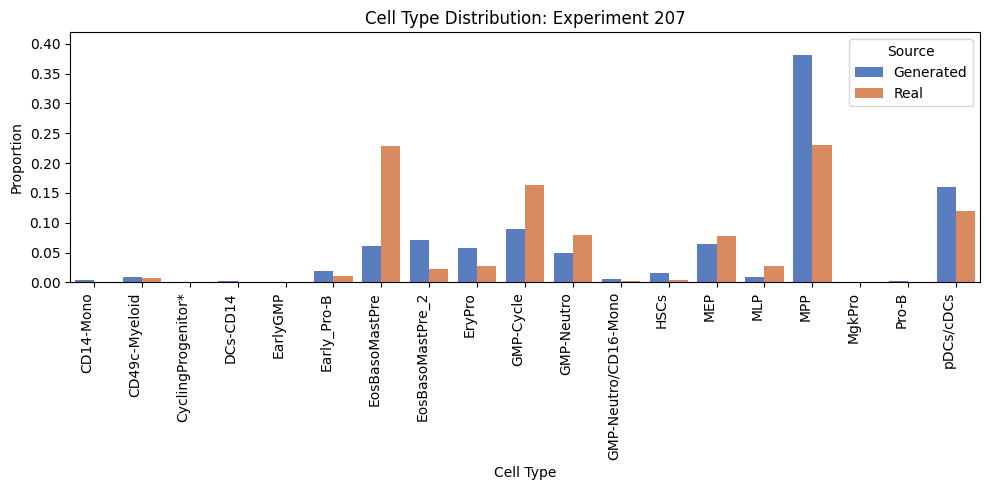

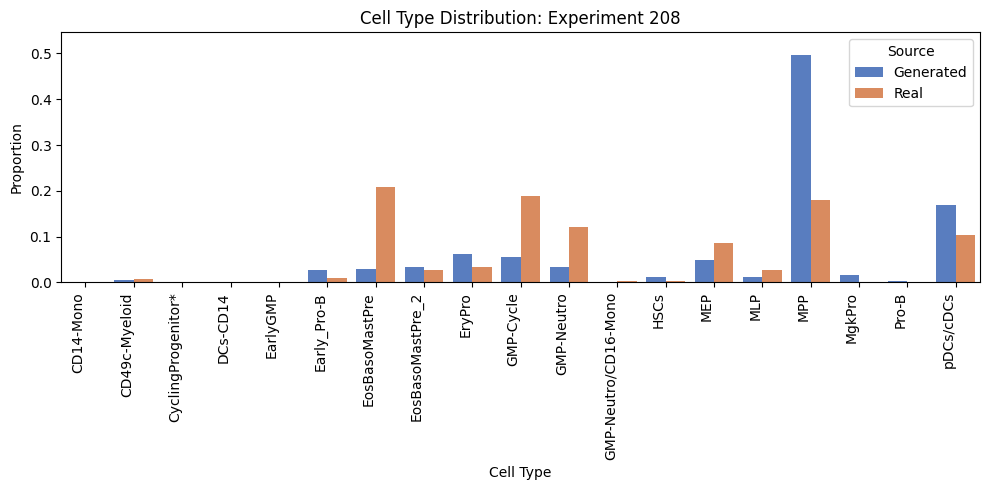

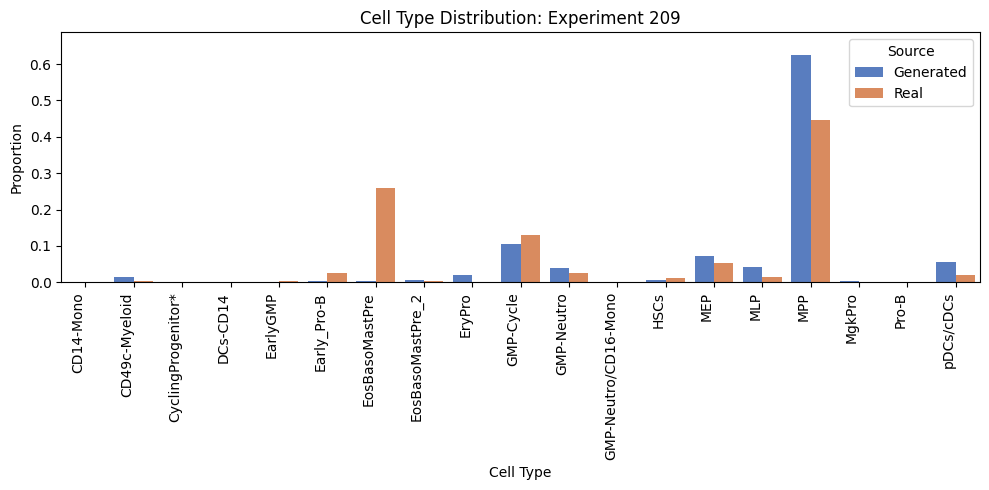

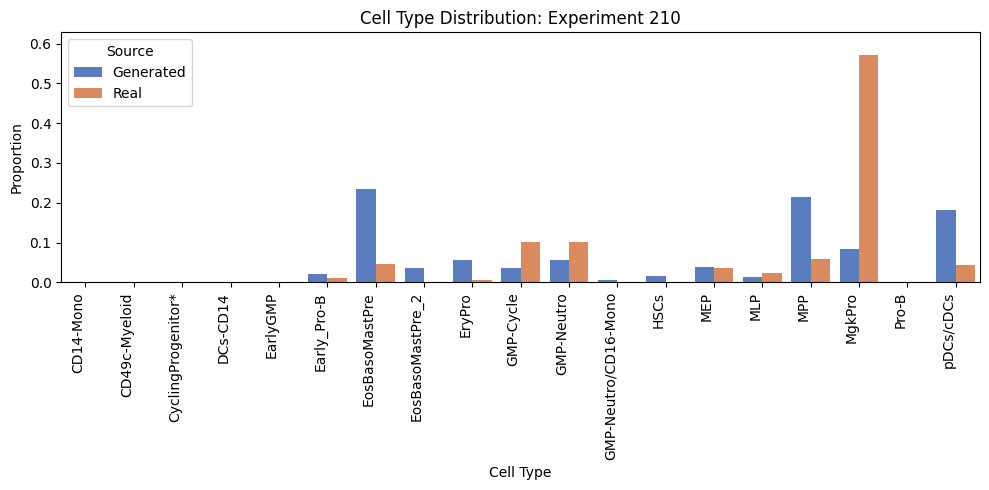

In [9]:
mean_ct_probs = sim_data["ct_probs"].mean(0)
exp_ct_props = {}
for idx, (exp_number, exp_idx) in enumerate(adata_real.obs.groupby("experiment_number").groups.items()):
    pred_ct_probs = mean_ct_probs[idx]
    real_ct_counts = le_ct.transform(adata_real[exp_idx].obs["cell_type"])
    
    real_ct_probs = np.zeros_like(pred_ct_probs)
    for idx in range(len(real_ct_probs)):
        mask = np.argwhere(real_ct_counts == idx)
        real_ct_probs[idx] = len(mask) / len(real_ct_counts)

    exp_ct_props[exp_number] = {
        "pred": pred_ct_probs,
        "real": real_ct_probs,
    }
    
    # 1. Prepare small dataframe for this specific experiment
    df_temp = pd.DataFrame({
        "Cell Type": np.tile(le_ct.classes_, 2),
        "Proportion": np.concatenate([pred_ct_probs, real_ct_probs]),
        "Source": ["Generated"] * len(le_ct.classes_) + ["Real"] * len(le_ct.classes_)
    })

    # 2. Create the figure
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_temp, x="Cell Type", y="Proportion", hue="Source", palette="muted")
    
    # 3. Formatting
    plt.title(f"Cell Type Distribution: Experiment {exp_number}")
    plt.xticks(rotation=90, ha='right')
    plt.ylabel("Proportion")
    plt.ylim(0, max(df_temp["Proportion"]) * 1.1) # Add a little headroom
    plt.tight_layout()
    
    # 4. Display or Save
    plt.savefig(
        os.path.join(dump_dir, f"ct_props_{exp_number}.png"),
        dpi=300
    )

## UQ.

### Prepare populations.

In [14]:
n_pops = 10
n_iters = 100
uq_data_per_cond = {}
ct_probs = sim_data["ct_probs"]
for idx, (exp_number, exp_idx) in tqdm(enumerate(adata_real.obs.groupby("experiment_number").groups.items())):
    pred_ct_probs = ct_probs[:, idx]
    populations = get_shuffled_populations(pred_ct_probs, n_pops=n_pops, n_iters=n_iters)
    uq_data_per_cond[exp_number] = populations

/tmp/ipykernel_2628400/4112932884.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (exp_number, exp_idx) in tqdm(enumerate(adata_real.obs.groupby("experiment_number").groups.items())):
6it [00:00, 137.47it/s]


### Compute Variance of Mean per cell type. 

In [15]:
uq_mean_std_mean = {}
uq_std_std_mean = {}
for exp_number, populations in uq_data_per_cond.items():
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    uq_mean_std_mean[exp_number] = shuffled_mean_std_mean_probs
    uq_std_std_mean[exp_number] = shuffled_std_std_mean_probs


### Visualize results.

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2628400/3682995477.py:40: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Mean $\sigma$ across shuffles", fontsize=12)


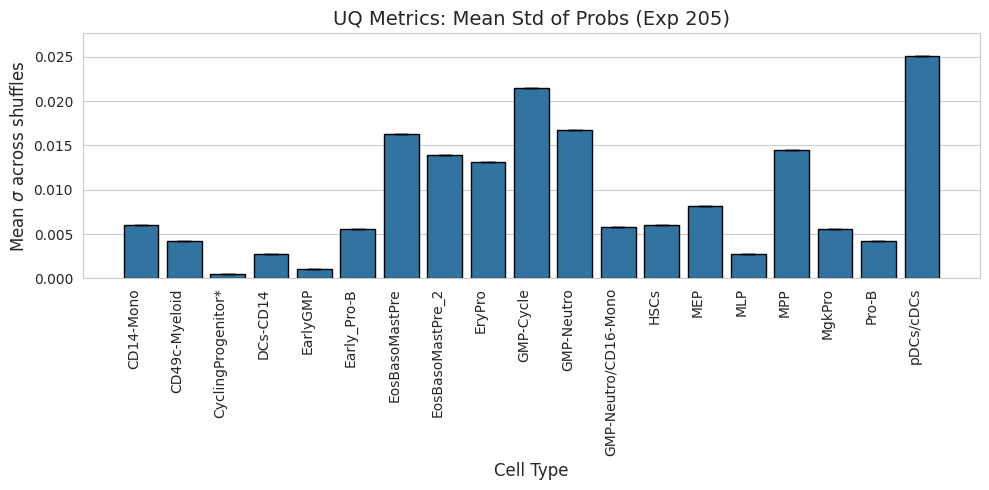

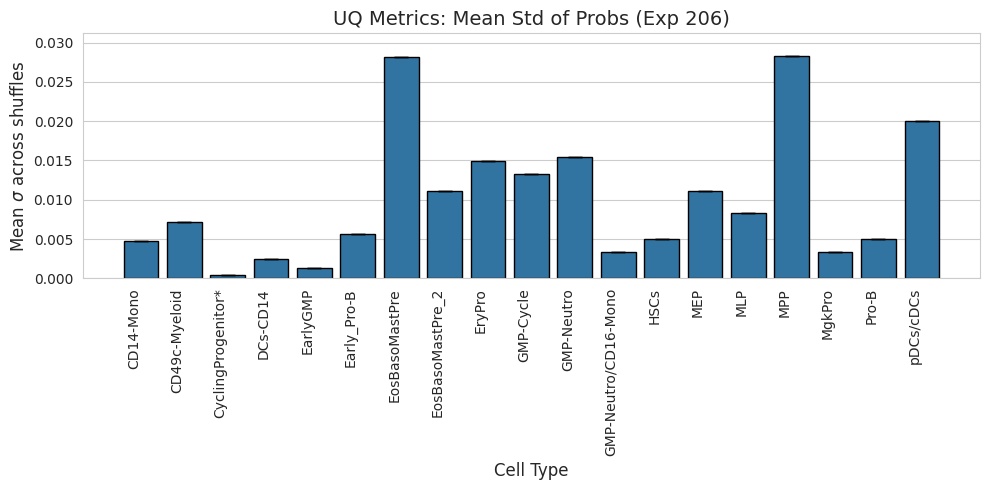

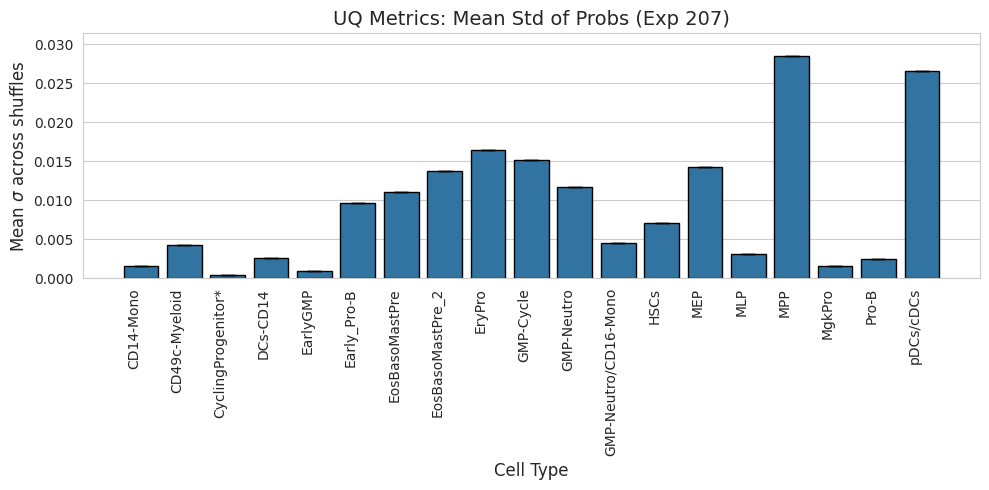

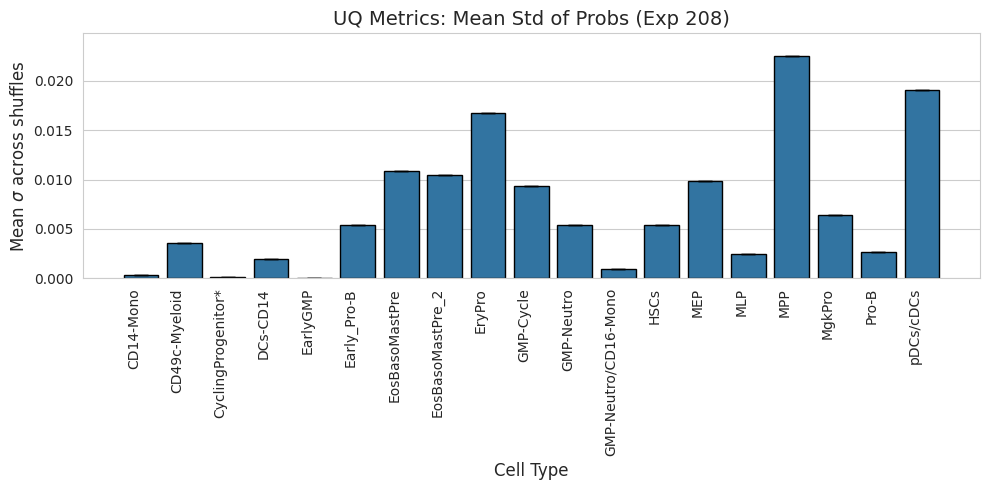

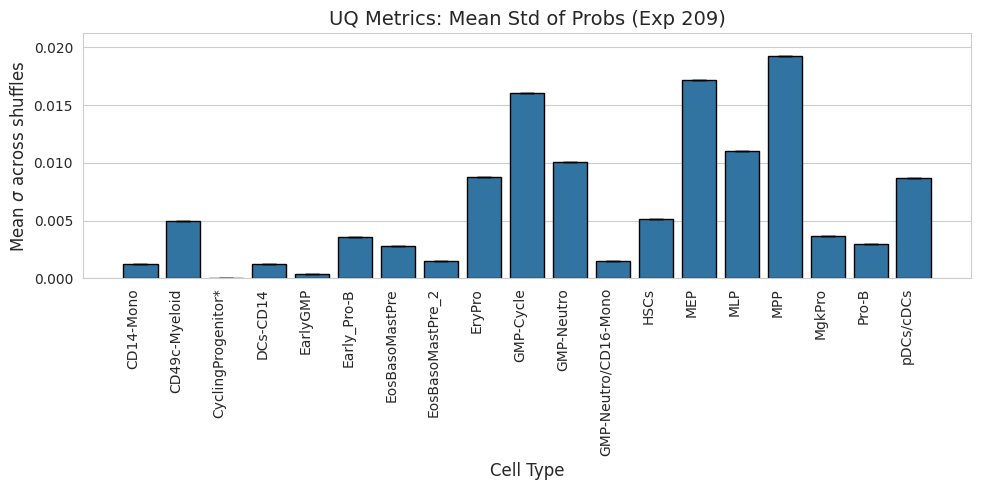

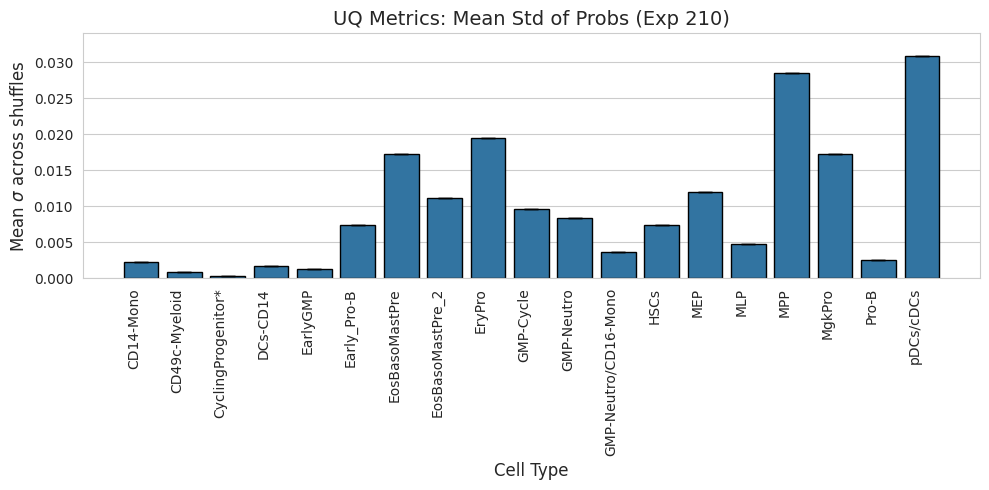

In [16]:
# Assuming uq_data_per_cond and le_ct are defined
cell_type_names = le_ct.classes_

for exp_number, populations in uq_data_per_cond.items():
    # --- Your calculation logic ---
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    
    uq_mean_std_mean[exp_number] = shuffled_mean_std_mean_probs
    uq_std_std_mean[exp_number] = shuffled_std_std_mean_probs

    # --- PLOTTING PER EXPERIMENT ---
    
    plt.figure(figsize=(10, 5))
    
    # Create the bar plot for the mean uncertainty
    # x: Cell Type names, y: The mean of the standard deviations
    sns.barplot(
        x=cell_type_names, 
        y=shuffled_mean_std_mean_probs,
        # palette="magma",
        edgecolor="black"
    )

    # Add error bars manually using the std_std_mean
    plt.errorbar(
        x=np.arange(len(cell_type_names)), 
        y=shuffled_mean_std_mean_probs, 
        yerr=shuffled_std_std_mean_probs, 
        fmt='none', 
        c='black', 
        capsize=5
    )

    # Formatting
    plt.title(f"UQ Metrics: Mean Std of Probs (Exp {exp_number})", fontsize=14)
    plt.xlabel("Cell Type", fontsize=12)
    plt.ylabel("Mean $\sigma$ across shuffles", fontsize=12)
    plt.xticks(rotation=90, ha='right')
    
    # Optional: adjust y-axis to make room for error bars
    y_max = (shuffled_mean_std_mean_probs + shuffled_std_std_mean_probs).max()
    plt.ylim(0, y_max * 1.1)
    
    plt.tight_layout()
    # 4. Display or Save
    plt.savefig(
        os.path.join(dump_dir, f"ct_props_uq_mean_std_{exp_number}.png"),
        dpi=300
    )
    plt.show()



### Displaying sum of standard deviations.

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2628400/1709283562.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Sum of Mean $\sigma$ across Cell Types")
/tmp/ipykernel_2628400/1709283562.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


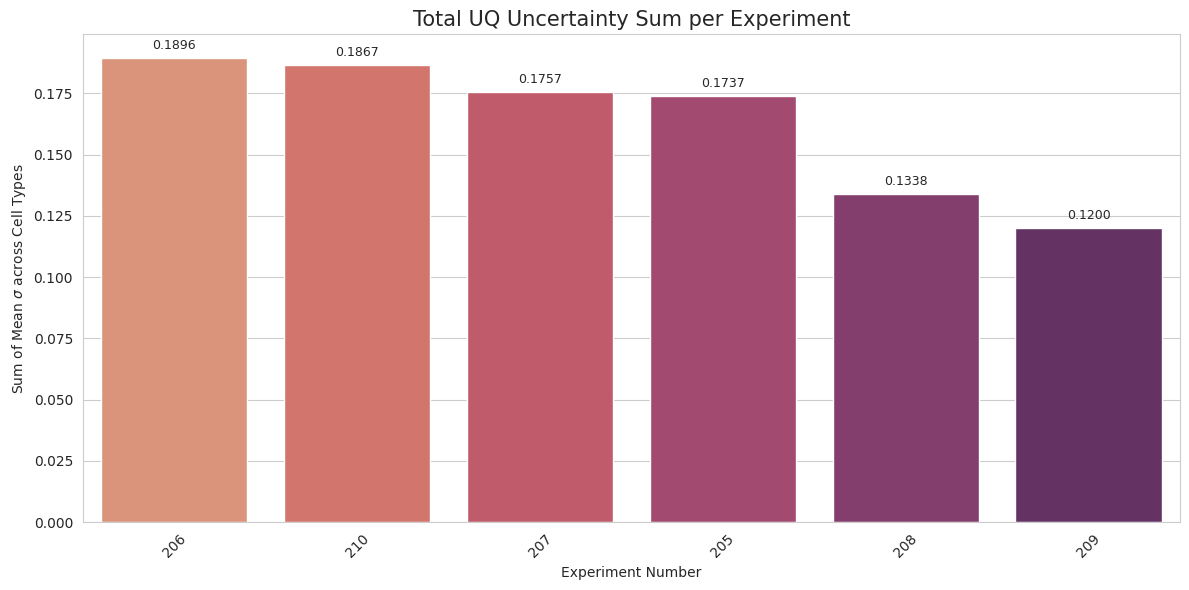

In [17]:
# Assuming uq_data_per_cond and le_ct are defined
cell_type_names = le_ct.classes_

uq_mean_std_mean_sum = {}

for exp_number, populations in uq_data_per_cond.items():
    # --- Your calculation logic ---
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    
    uq_mean_std_mean_sum[exp_number] = shuffled_mean_std_mean_probs.sum()

#  1. Convert dictionary to DataFrame for Seaborn
summary_df = pd.DataFrame({
    "Experiment": list(uq_mean_std_mean_sum.keys()),
    "Total Uncertainty": list(uq_mean_std_mean_sum.values())
})

# Optional: Sort by uncertainty to see the most/least stable experiments
summary_df = summary_df.sort_values("Total Uncertainty", ascending=False)

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=summary_df, 
    x="Experiment", 
    y="Total Uncertainty", 
    palette="flare"
)

# 3. Aesthetics
plt.title("Total UQ Uncertainty Sum per Experiment", fontsize=15)
plt.ylabel("Sum of Mean $\sigma$ across Cell Types")
plt.xlabel("Experiment Number")
plt.xticks(rotation=45)

# Add value labels on top of bars for precision
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()

# 4. Display or Save
plt.savefig(
    os.path.join(dump_dir, f"ct_props_uq_mean_sum_std.png"),
    dpi=300
)
plt.show()

plt.show()

### Compare cell states.

In [96]:
from collections import defaultdict

exp_numbers = sorted(adata_real.obs["experiment_number"].unique())

edist_dict = defaultdict(list)

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # retrieve simulations for current experiment
    X_channel_gen = sim_data["X_channel"][:, gen_idx, :]
    X_scatter_gen = sim_data["X_scatter"][:, gen_idx, :]

    print(f"g:{gen_exp_number} -> GENERATED: {X_channel_gen.shape=}, {X_scatter_gen.shape=} -> {gen_idx+1}/{len(exp_numbers)}")

    for idx, exp_number in enumerate(exp_numbers):
        # retrieve real data
        adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
        X_channel_real = adata_exp.obsm["X_channel_standardized"]
        X_scatter_real = adata_exp.obsm["X_scatter_standardized"]
        print(f"g:{gen_exp_number}/r:{exp_number} -> REAL: {X_channel_real.shape=}, {X_scatter_real.shape=} -> g:{gen_idx+1}/{len(exp_numbers)} | r:{idx+1}/{len(exp_numbers)}")
        edist = compute_e_distance(X_channel_gen, X_channel_real)
        edist_dict["gen_exp_number"].append(gen_exp_number)
        edist_dict["real_exp_number"].append(exp_number)
        edist_dict["edist"].append(edist)
distance_df = pd.DataFrame(edist_dict).sort_values("edist", axis=0, ascending=False)
distance_df

g:205 -> GENERATED: X_channel_gen.shape=(2500, 21), X_scatter_gen.shape=(2500, 6) -> 1/6
g:205/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:1/6 | r:1/6
g:205/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:1/6 | r:2/6
g:205/r:207 -> REAL: X_channel_real.shape=(15779, 21), X_scatter_real.shape=(15779, 6) -> g:1/6 | r:3/6
g:205/r:208 -> REAL: X_channel_real.shape=(25828, 21), X_scatter_real.shape=(25828, 6) -> g:1/6 | r:4/6
g:205/r:209 -> REAL: X_channel_real.shape=(5942, 21), X_scatter_real.shape=(5942, 6) -> g:1/6 | r:5/6
g:205/r:210 -> REAL: X_channel_real.shape=(19498, 21), X_scatter_real.shape=(19498, 6) -> g:1/6 | r:6/6
g:206 -> GENERATED: X_channel_gen.shape=(2500, 21), X_scatter_gen.shape=(2500, 6) -> 2/6
g:206/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:2/6 | r:1/6
g:206/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:2/6 

,gen_exp_number,real_exp_number,edist
29,209,210,514.699446
17,207,210,510.296511
11,206,210,498.298265
5,205,210,492.663193
23,208,210,487.406495
35,210,210,403.011360
24,209,205,27.647961
28,209,209,25.404864
22,208,209,24.366498
25,209,206,21.916783


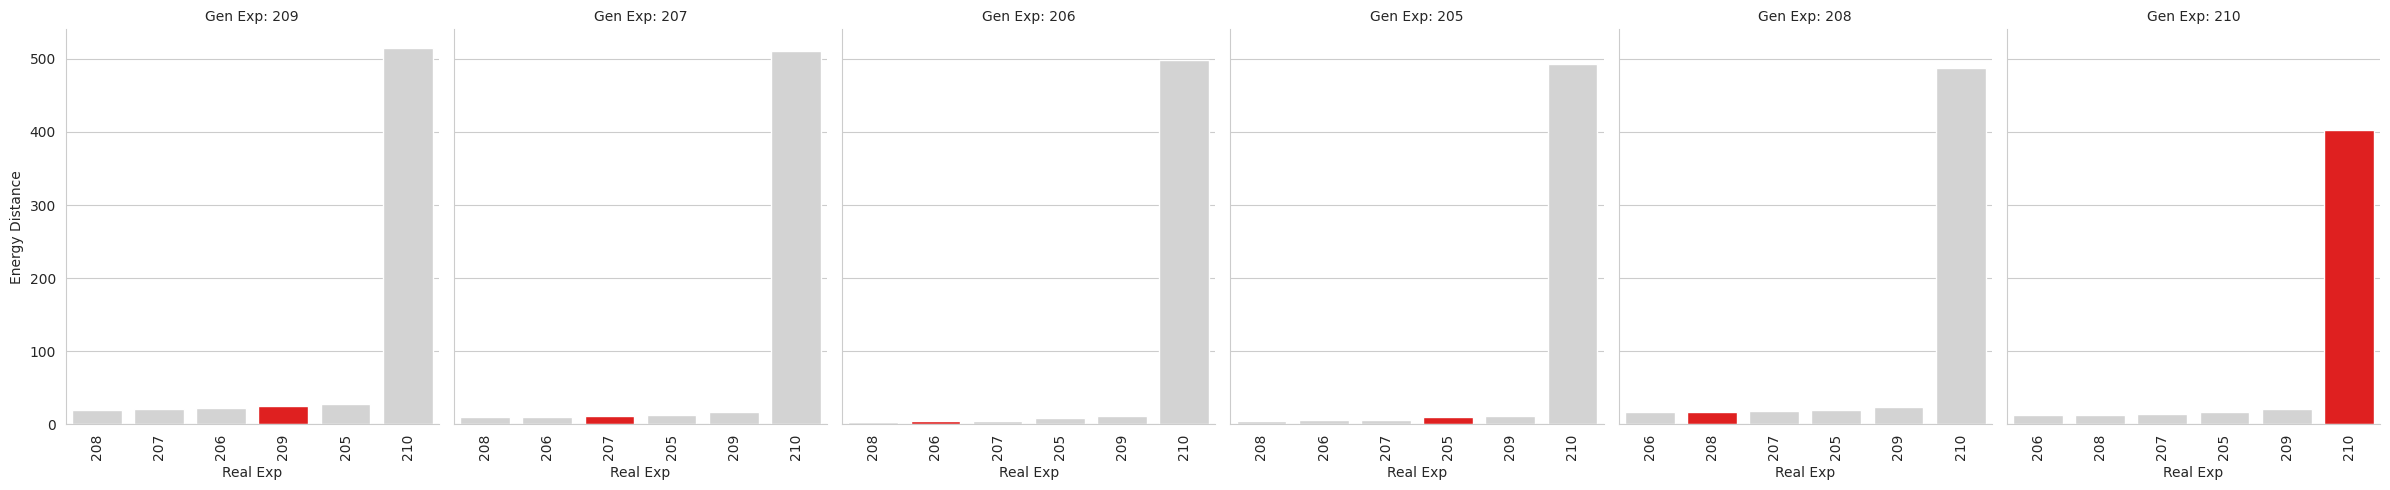

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Flag the matches for conditional coloring
distance_df['is_match'] = distance_df['gen_exp_number'] == distance_df['real_exp_number']

# 2. Setup the FacetGrid in one row (no col_wrap)
g = sns.FacetGrid(
    distance_df, 
    col="gen_exp_number", 
    height=5, 
    aspect=0.8, 
    sharex=False
)

# 3. Define the plotting function to sort bars and color them
def plot_sorted_gray_red(data, **kwargs):
    # Sort by 'edist' to follow bar sorting guidelines
    data_sorted = data.sort_values("edist")
    
    # Plot bars: Red for the match, Gray for others
    sns.barplot(
        data=data_sorted, 
        x="real_exp_number", 
        y="edist", 
        hue="is_match", 
        palette={True: "red", False: "lightgray"}, 
        dodge=False
    )

# 4. Map to the grid
g.map_dataframe(plot_sorted_gray_red)

# 5. Final Formatting
g.set_axis_labels("Real Exp", "Energy Distance")
g.set_titles("Gen Exp: {col_name}")

# Remove individual legends from each facet
for ax in g.axes.flat:
    if ax.get_legend():
        ax.get_legend().remove()
    ax.tick_params(axis='x', rotation=90) # Rotate labels for clarity in single row

plt.tight_layout()
# plt.savefig("energy_distance_single_row.png")

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

stats_list = []

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # Combine generated channels and scatter
    X_gen = np.hstack([sim_data["X_channel"][:, gen_idx, :], 
                       sim_data["X_scatter"][:, gen_idx, :]])
    print(X_gen.shape)
    # Compute stats per dimension (axis=0)
    mean_gen = np.mean(X_gen, axis=0)
    std_gen = np.std(X_gen, axis=0)

    for idx, exp_number in enumerate(exp_numbers):
        # Retrieve and combine real data
        adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
        X_real = np.hstack([adata_exp.obsm["X_channel_standardized"], 
                            adata_exp.obsm["X_scatter_standardized"]])
        print(X_real.shape)    
        mean_real = np.mean(X_real, axis=0)
        std_real = np.std(X_real, axis=0)
        
        # Store for plotting (one row per dimension/feature)
        for i in range(X_gen.shape[1]):
            stats_list.append({
                "gen_exp": gen_exp_number,
                "real_exp": exp_number,
                "dim_idx": i,
                "mean_gen": mean_gen[i],
                "mean_real": mean_real[i],
                "std_gen": std_gen[i],
                "std_real": std_real[i],
                "is_match": gen_exp_number == exp_number
            })

df_stats = pd.DataFrame(stats_list)

(2500, 27)
(12936, 27)
(20017, 27)
(15779, 27)
(25828, 27)
(5942, 27)
(19498, 27)
(2500, 27)
(12936, 27)
(20017, 27)
(15779, 27)
(25828, 27)
(5942, 27)
(19498, 27)
(2500, 27)
(12936, 27)
(20017, 27)
(15779, 27)
(25828, 27)
(5942, 27)
(19498, 27)
(2500, 27)
(12936, 27)
(20017, 27)
(15779, 27)
(25828, 27)
(5942, 27)
(19498, 27)
(2500, 27)
(12936, 27)
(20017, 27)
(15779, 27)
(25828, 27)
(5942, 27)
(19498, 27)
(2500, 27)
(12936, 27)
(20017, 27)
(15779, 27)
(25828, 27)
(5942, 27)
(19498, 27)


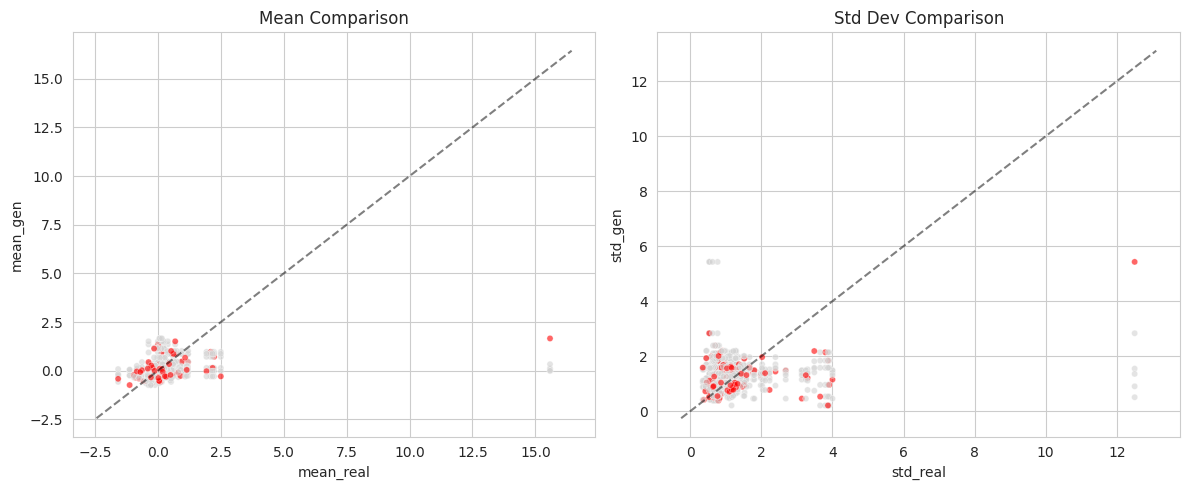

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot settings
plot_params = [
    ("mean_real", "mean_gen", "Mean Comparison", axes[0]),
    ("std_real", "std_gen", "Std Dev Comparison", axes[1])
]

for x_col, y_col, title, ax in plot_params:
    # Plot non-matches in gray first, then matches in red
    sns.scatterplot(
        data=df_stats, x=x_col, y=y_col, hue="is_match",
        palette={True: "red", False: "lightgray"}, alpha=0.6, ax=ax, s=20
    )
    
    # Add X=Y identity line
    lo, hi = ax.get_xlim(), ax.get_ylim()
    min_val, max_val = min(lo[0], hi[0]), max(lo[1], hi[1])
    ax.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", alpha=0.5)
    
    ax.set_title(title)
    ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [100]:
from collections import defaultdict

exp_numbers = sorted(adata_real.obs["experiment_number"].unique())

edist_dict_rr = defaultdict(list)

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # retrieve simulations for current experiment

    adata_exp_i = adata_real[adata_real.obs["experiment_number"] == exp_number]
    X_channel_gen = adata_exp_i.obsm["X_channel_standardized"]
    X_scatter_gen = adata_exp_i.obsm["X_scatter_standardized"]

    print(f"g:{gen_exp_number} -> GENERATED: {X_channel_gen.shape=}, {X_scatter_gen.shape=} -> {gen_idx+1}/{len(exp_numbers)}")

    for idx, exp_number in enumerate(exp_numbers):
        # retrieve real data
        adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
        X_channel_real = adata_exp.obsm["X_channel_standardized"]
        X_scatter_real = adata_exp.obsm["X_scatter_standardized"]
        print(f"g:{gen_exp_number}/r:{exp_number} -> REAL: {X_channel_real.shape=}, {X_scatter_real.shape=} -> g:{gen_idx+1}/{len(exp_numbers)} | r:{idx+1}/{len(exp_numbers)}")
        edist = compute_e_distance(X_channel_gen, X_channel_real)
        edist_dict_rr["gen_exp_number"].append(gen_exp_number)
        edist_dict_rr["real_exp_number"].append(exp_number)
        edist_dict_rr["edist"].append(edist)
distance_df_rr = pd.DataFrame(edist_dict_rr).sort_values("edist", axis=0, ascending=False)
distance_df_rr

g:205 -> GENERATED: X_channel_gen.shape=(19498, 21), X_scatter_gen.shape=(19498, 6) -> 1/6
g:205/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:1/6 | r:1/6
g:205/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:1/6 | r:2/6
g:205/r:207 -> REAL: X_channel_real.shape=(15779, 21), X_scatter_real.shape=(15779, 6) -> g:1/6 | r:3/6
g:205/r:208 -> REAL: X_channel_real.shape=(25828, 21), X_scatter_real.shape=(25828, 6) -> g:1/6 | r:4/6
g:205/r:209 -> REAL: X_channel_real.shape=(5942, 21), X_scatter_real.shape=(5942, 6) -> g:1/6 | r:5/6
g:205/r:210 -> REAL: X_channel_real.shape=(19498, 21), X_scatter_real.shape=(19498, 6) -> g:1/6 | r:6/6
g:206 -> GENERATED: X_channel_gen.shape=(19498, 21), X_scatter_gen.shape=(19498, 6) -> 2/6
g:206/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:2/6 | r:1/6
g:206/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:

,gen_exp_number,real_exp_number,edist
22,208,209,504.967642
16,207,209,504.967642
10,206,209,504.967642
4,205,209,504.967642
28,209,209,504.967642
34,210,209,504.967642
30,210,205,504.782219
0,205,205,504.782219
24,209,205,504.782219
18,208,205,504.782219


In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

stats_rr_list = []

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # Retrieve 'Reference' Real Data (acting as 'gen' in this RR loop)
    adata_exp_i = adata_real[adata_real.obs["experiment_number"] == gen_exp_number]
    X_gen = np.hstack([adata_exp_i.obsm["X_channel_standardized"], 
                       adata_exp_i.obsm["X_scatter_standardized"]])
    
    # Stats per dimension (feature)
    mean_gen = np.mean(X_gen, axis=0)
    std_gen = np.std(X_gen, axis=0)

    for idx, exp_number in enumerate(exp_numbers):
        # Retrieve 'Target' Real Data
        adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
        X_real = np.hstack([adata_exp.obsm["X_channel_standardized"], 
                            adata_exp.obsm["X_scatter_standardized"]])
        
        mean_real = np.mean(X_real, axis=0)
        std_real = np.std(X_real, axis=0)
        
        # Capture stats for every single dimension/feature
        for d in range(X_gen.shape[1]):
            stats_rr_list.append({
                "gen_exp": gen_exp_number,
                "real_exp": exp_number,
                "dim_idx": d,
                "mean_ref": mean_gen[d],
                "mean_target": mean_real[d],
                "std_ref": std_gen[d],
                "std_target": std_real[d],
                "is_match": gen_exp_number == exp_number
            })

df_stats_rr = pd.DataFrame(stats_rr_list)

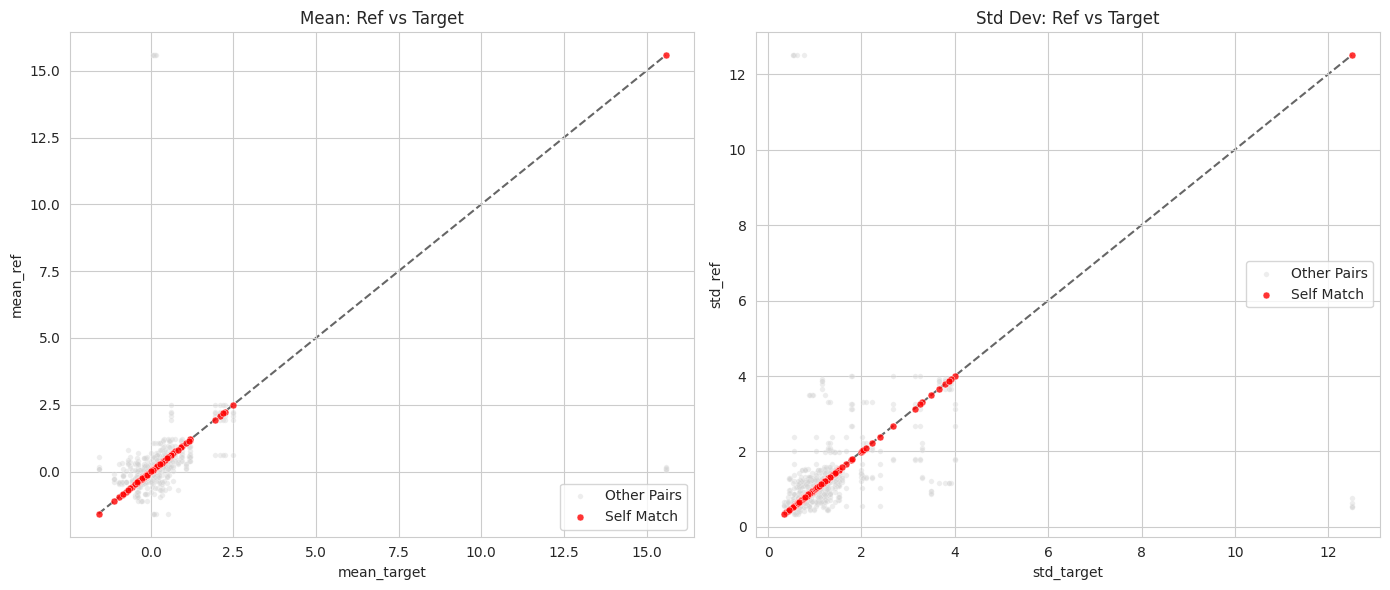

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_configs = [
    ("mean_target", "mean_ref", "Mean: Ref vs Target", axes[0]),
    ("std_target", "std_ref", "Std Dev: Ref vs Target", axes[1])
]

for x_col, y_col, title, ax in plot_configs:
    # 1. Plot non-matches in gray (background)
    sns.scatterplot(
        data=df_stats_rr[~df_stats_rr['is_match']], 
        x=x_col, y=y_col, color="lightgray", alpha=0.4, ax=ax, s=15, label="Other Pairs"
    )
    # 2. Plot self-matches in red (foreground)
    sns.scatterplot(
        data=df_stats_rr[df_stats_rr['is_match']], 
        x=x_col, y=y_col, color="red", alpha=0.8, ax=ax, s=25, label="Self Match"
    )
    
    # 3. Add the X=Y Identity Line
    max_val = max(df_stats_rr[x_col].max(), df_stats_rr[y_col].max())
    min_val = min(df_stats_rr[x_col].min(), df_stats_rr[y_col].min())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0)
    
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### Visualize predictions.

205 -> AnnData object with n_obs × n_vars = 82936 × 21
    obs: 'experiment_number', 'cell_type', 'dataset_type'
    obsm: 'X_scatter'


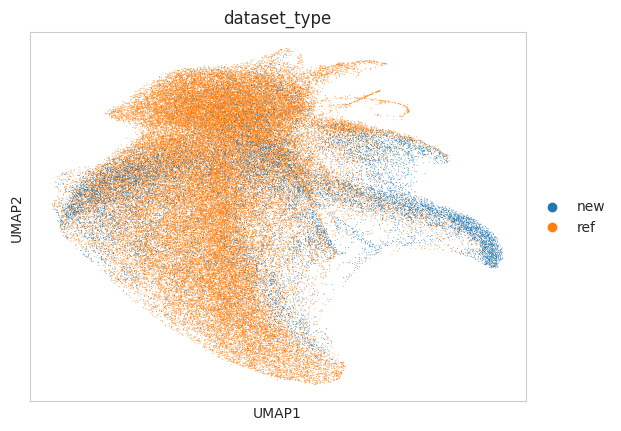

206 -> AnnData object with n_obs × n_vars = 90017 × 21
    obs: 'experiment_number', 'cell_type', 'dataset_type'
    obsm: 'X_scatter'


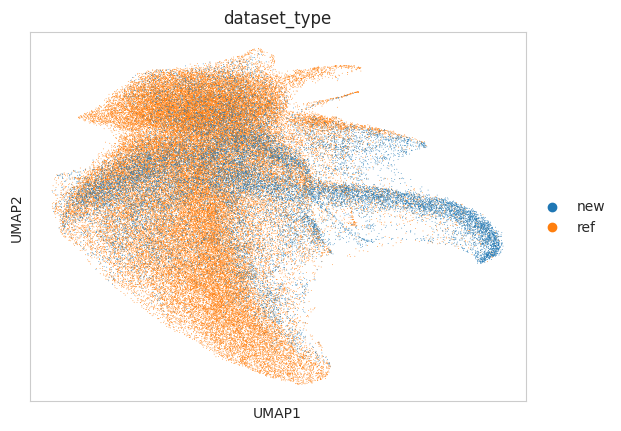

207 -> AnnData object with n_obs × n_vars = 85779 × 21
    obs: 'experiment_number', 'cell_type', 'dataset_type'
    obsm: 'X_scatter'


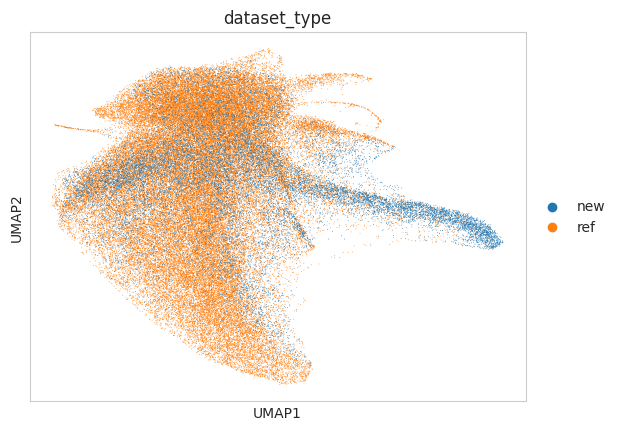

208 -> AnnData object with n_obs × n_vars = 95828 × 21
    obs: 'experiment_number', 'cell_type', 'dataset_type'
    obsm: 'X_scatter'


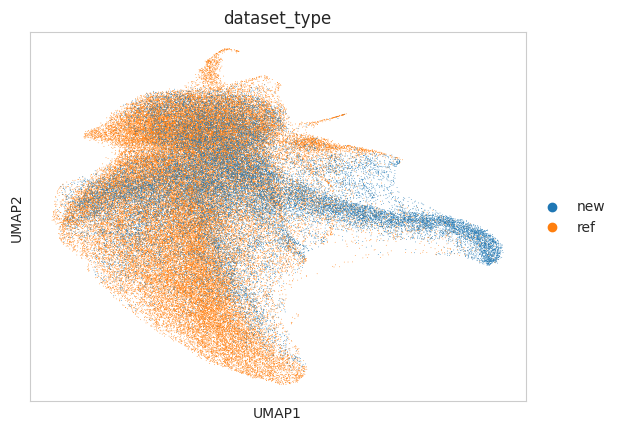

209 -> AnnData object with n_obs × n_vars = 75942 × 21
    obs: 'experiment_number', 'cell_type', 'dataset_type'
    obsm: 'X_scatter'


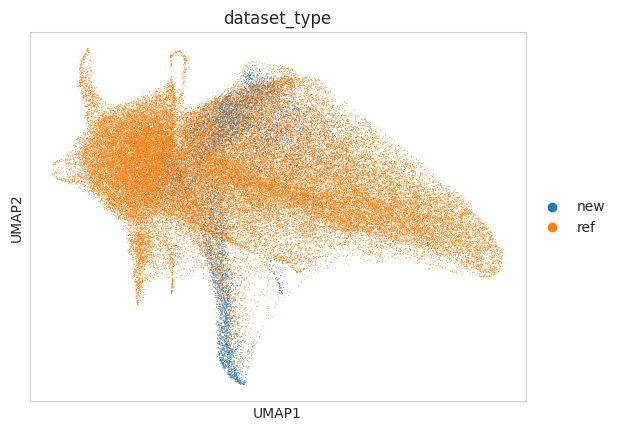

210 -> AnnData object with n_obs × n_vars = 89498 × 21
    obs: 'experiment_number', 'cell_type', 'dataset_type'
    obsm: 'X_scatter'


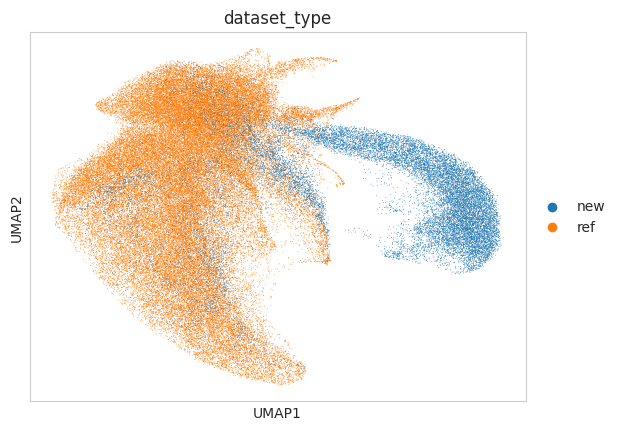

In [143]:
exp2adata = {}

# retrieve reference data
# X_channel_ref = adata_class.obsm["X_channel_renormalized"]
# X_scatter_ref = adata_class.obsm["X_scatter_renormalized"]
X_channel_ref = adata_class.X
X_scatter_ref = adata_class.obsm["X_scatter_renormalized"]

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # retrieve simulations for current experiment
    X_channel_gen = sim_data["X_channel"][:, gen_idx, :]
    X_scatter_gen = sim_data["X_scatter"][:, gen_idx, :]
    ct_probs_gen = sim_data["ct_probs"][:, gen_idx, :]

    # retrieve real data for current experiment
    adata_exp = adata_real[adata_real.obs["experiment_number"] == gen_exp_number]
    # X_channel_real = adata_exp.obsm["X_channel_standardized"]
    # X_scatter_real = adata_exp.obsm["X_scatter_standardized"]

    X_channel_real = adata_exp.X
    X_scatter_real = adata_exp.obsm["X_scatter_standardized"]

    # compute cell type
    ct_gen = le_ct.inverse_transform(
        ct_probs_gen.argmax(-1)
    )

    # create adata
    adata_exp_concat = sc.AnnData(
        X=np.concatenate(
            (
                X_channel_ref,
                X_channel_real,
                # X_channel_gen,
            ),
            axis=0
        ),
        obs={
            "experiment_number": adata_class.obs["experiment_number"].tolist() + \
                adata_exp.obs["experiment_number"].tolist(), #+ \
                # [gen_exp_number for _ in range(X_channel_gen.shape[0])],
            "cell_type": adata_class.obs["cell_type"].tolist() + \
                adata_exp.obs["cell_type"].tolist(), #+ \
                # ct_gen.tolist(),
            "dataset_type": ["ref" for _ in range(adata_class.shape[0])] + \
                ["new" for _ in range(adata_exp.shape[0])] #+ \
                # ["gen" for _ in range(X_channel_gen.shape[0])]
        },
        obsm={
            "X_scatter": np.concatenate(
                (
                    X_scatter_ref,
                    X_scatter_real,
                    # X_scatter_gen,
                ),
                axis=0
            ),
        }
    )
    print(f"{gen_exp_number} -> {adata_exp_concat}")
    sc.pp.pca(adata_exp_concat)
    sc.pp.neighbors(adata_exp_concat)
    sc.tl.umap(adata_exp_concat)
    sc.pl.embedding(adata_exp_concat, "umap", color="dataset_type")
    exp2adata[gen_exp_number] = adata_exp_concat

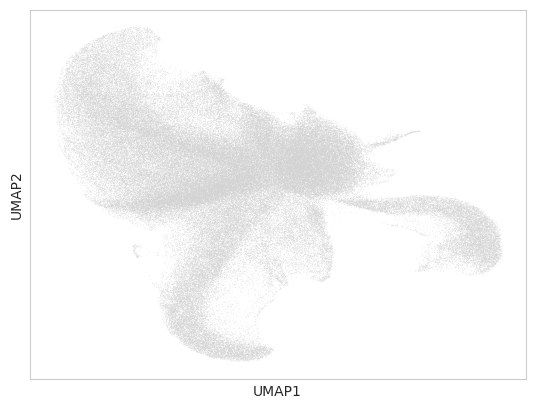

In [ ]:
adata_concat = sc.concat((adata_class, adata_real), uns_merge="same")
sc.pp.pca(adata_concat)
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)
sc.pl.embedding(adata_concat, "umap")


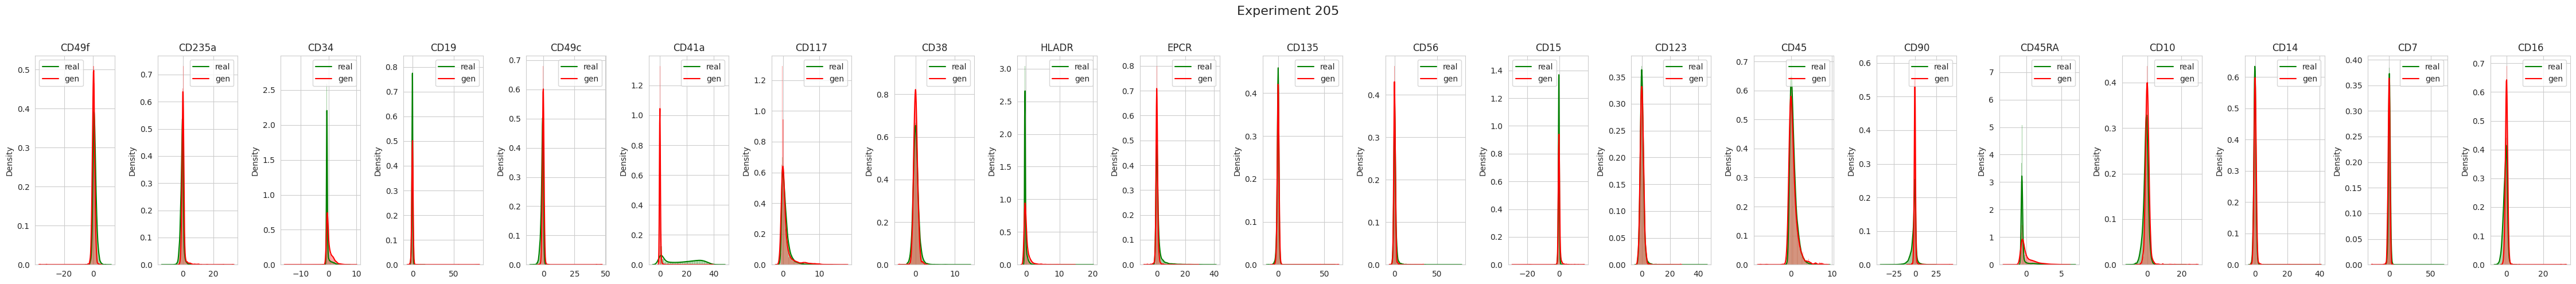

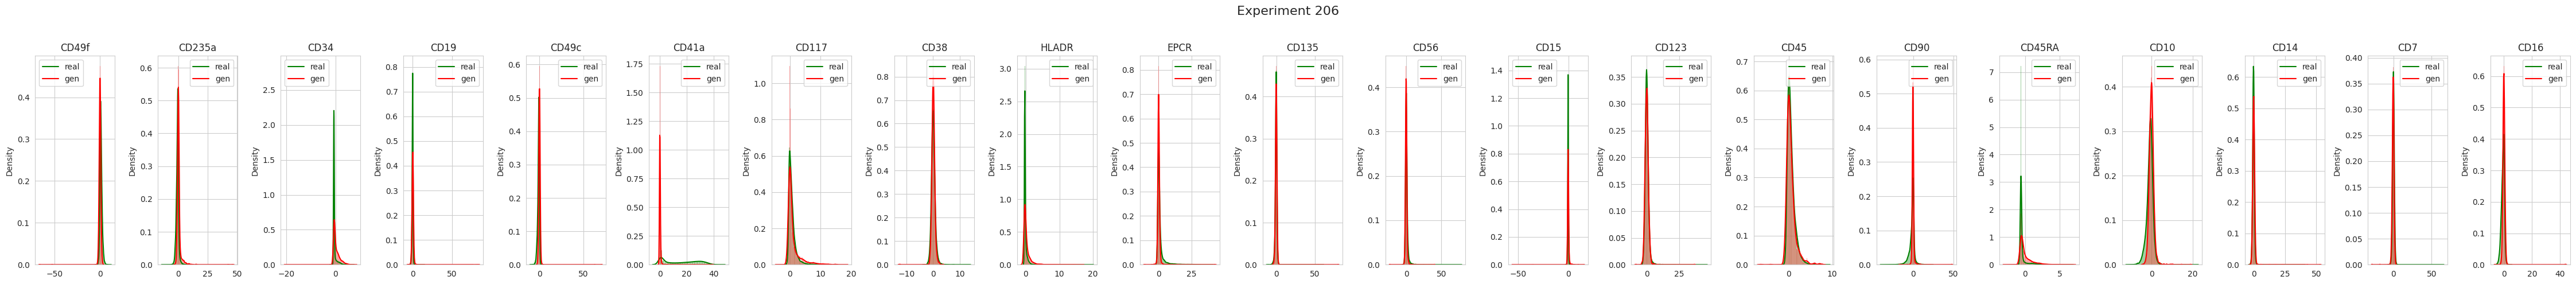

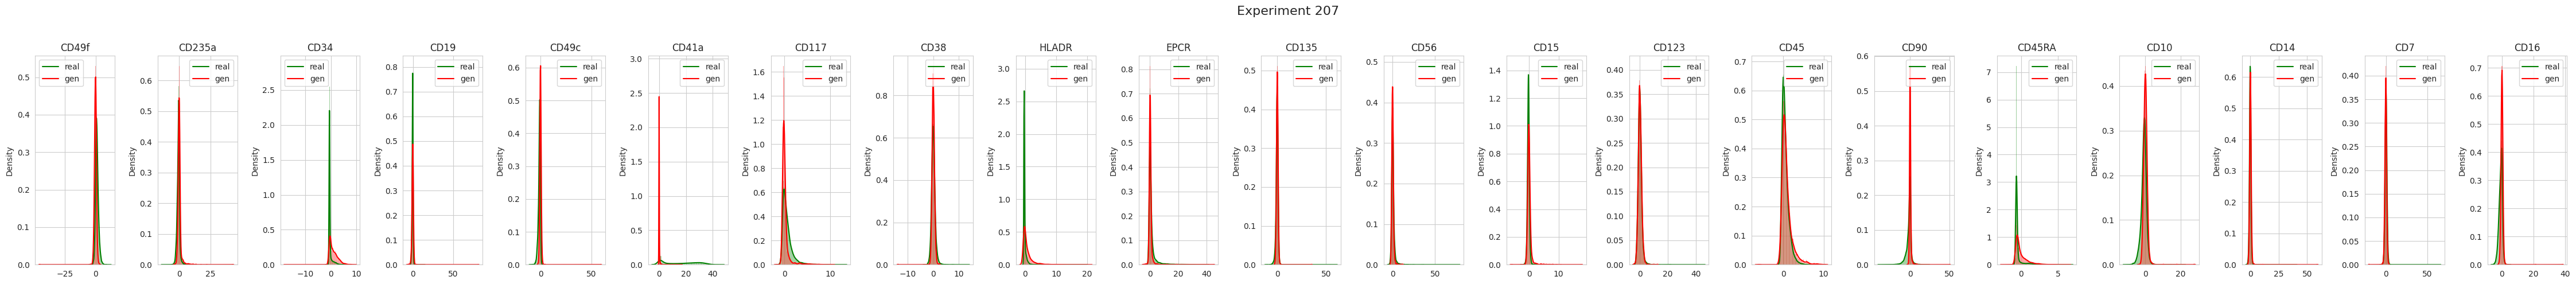

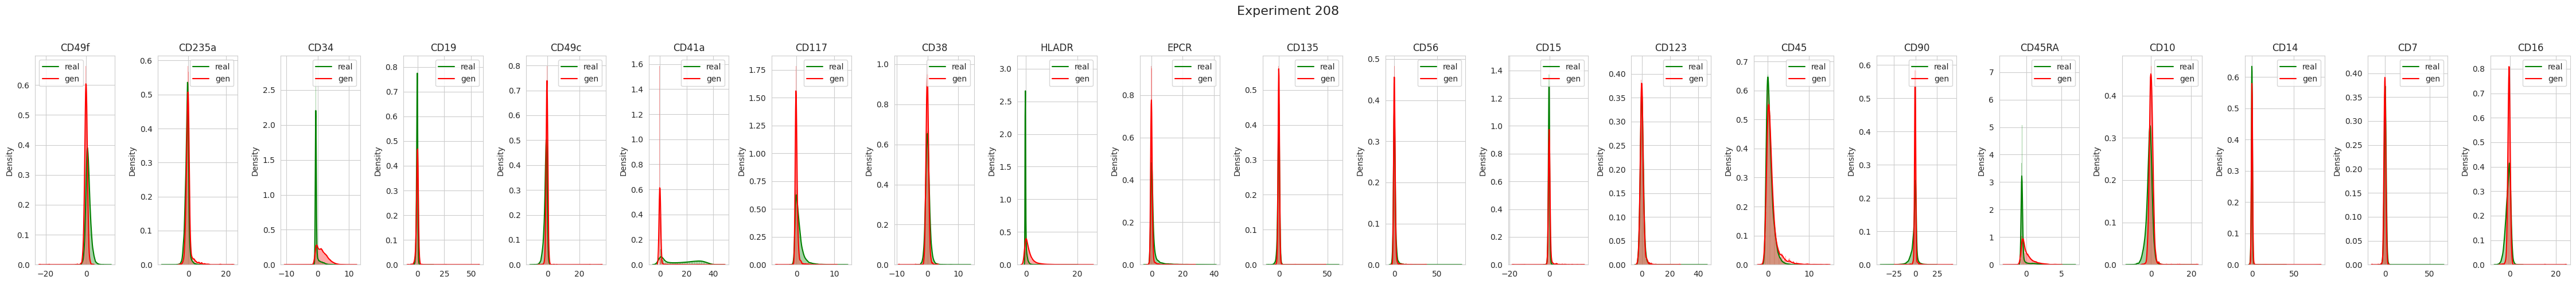

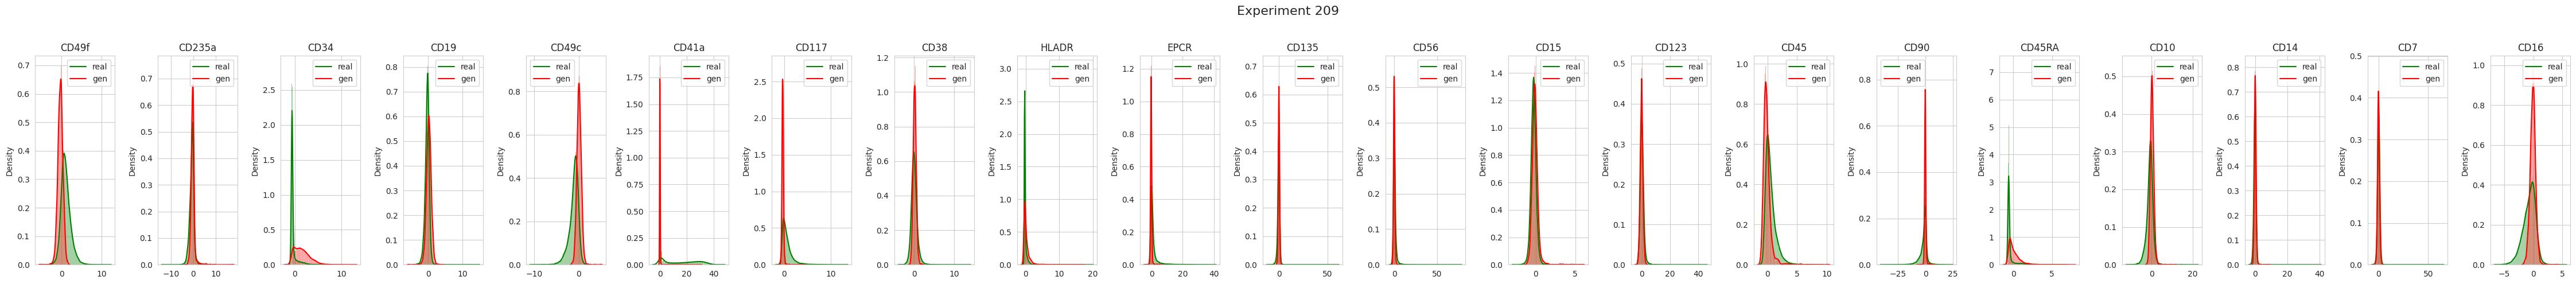

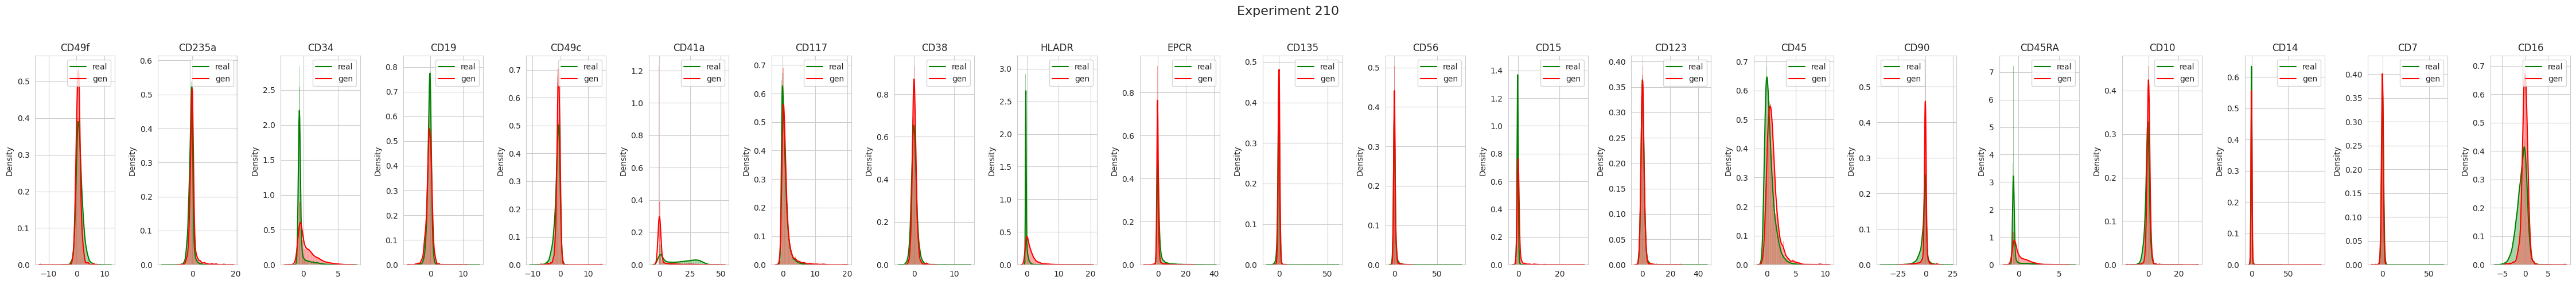

In [148]:
from plot_utils import plot_marginals
adata_ref = cfm.train_data.adata
for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # retrieve simulations for current experiment
    X_channel_gen = sim_data["X_channel"][:, gen_idx, :]
    X_scatter_gen = sim_data["X_scatter"][:, gen_idx, :]
    ct_probs_gen = sim_data["ct_probs"][:, gen_idx, :]

    # retrieve real data for current experiment
    adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
    X_channel_real = adata_exp.obsm["X_channel_standardized"]
    X_scatter_real = adata_exp.obsm["X_scatter_standardized"]

    # retrieve real data for current experiment
    # adata_ref_exp = adata_ref[adata_real.obs["experiment_number"] == exp_number]
    # X_channel_real = adata_ref_exp.obsm["X_channel_standardized"]
    # X_scatter_real = adata_ref_exp.obsm["X_scatter_standardized"]

    plot_marginals(X_channel_real, X_gen=X_channel_gen, col_names=adata_real.var_names, title=f"Experiment {gen_exp_number}")
    # break

